# Informasi Terkait DC

In [1]:
!pip install openpyxl


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

# Load dari Excel
xls = pd.ExcelFile("dataset/1742574481558_Dataset-ME-2025.xlsx")
df_dc = pd.read_excel(xls, sheet_name="DC Final")

# --- Bersihkan dan Standarisasi Kolom ---
df_dc.columns = df_dc.columns.str.strip().str.lower().str.replace(" ", "_")

# --- Ambil Kolom Penting ---
df_node = df_dc[[
    'dc_id',           # node_id
    'type',            # node_type
    'area',            # lokasi spesifik node
    'distributor_area',# regional / cakupan
    'latitude',
    'longitude',
    'sent_from'
]].dropna(subset=['dc_id', 'latitude', 'longitude'])

# --- Rename agar sesuai format standar node ---
df_node = df_node.rename(columns={
    'dc_id': 'node_id',
    'type': 'node_type',
    'area': 'location_name',
    'distributor_area': 'region'
})


# --- Pastikan koordinat dalam format float ---
df_node['latitude'] = df_node['latitude'].astype(str).str.replace(',', '.').astype(float)
df_node['longitude'] = df_node['longitude'].astype(str).str.replace(',', '.').astype(float)

# --- (Opsional) Drop duplikat ---
df_node = df_node.drop_duplicates(subset='node_id')

# Koordinat umum Karawang (bisa disesuaikan)
karawang_lat = -6.305384
karawang_lon = 107.296913

# Tambahkan SDC ke df_node
df_node = pd.concat([
    df_node,
    pd.DataFrame([{
        'node_id': 'SDC',
        'node_type': 'Pabrik',
        'location_name': 'Karawang',
        'region': 'Jawa Barat',
        'latitude': karawang_lat,
        'longitude': karawang_lon,
        'sent_from': None
    }])
], ignore_index=True)


# --- Lihat hasil ---
print(df_node.head())


  node_id node_type   location_name      region  latitude   longitude  \
0   DC001      Depo  Ampah - Teweh   Kalimantan -0.935414  114.901123   
1   DC002      Depo         Amurang   BCP Outer  1.255330  124.631870   
2   DC003      Depo         Barabai  Kalimantan -2.581936  115.390569   
3   DC004      Depo           Barru   BCP Outer -4.405620  119.618770   
4   DC005      Depo       Batulicin  Kalimantan -3.455801  115.997490   

   sent_from  
0        NaN  
1     Manado  
2        NaN  
3  Pare-Pare  
4        NaN  


In [3]:
df_edge = df_node[df_node['sent_from'].notna()].copy()

# Buat kolom edge_from dan edge_to
df_edge['edge_from'] = df_edge['sent_from']
df_edge['edge_to'] = df_edge['location_name']

# Sekalian ambil ID node yang sesuai
df_edge = df_edge.merge(df_node[['location_name', 'node_id']], how='left', left_on='edge_from', right_on='location_name', suffixes=('', '_from'))
df_edge = df_edge.merge(df_node[['location_name', 'node_id']], how='left', left_on='edge_to', right_on='location_name', suffixes=('', '_to'))

# Bersihin kolom
df_edges_clean = df_edge[[
    'node_id_from', 'node_id_to'
]].rename(columns={
    'node_id_from': 'from_node',
    'node_id_to': 'to_node'
})

df_edges_clean.head()

,from_node,to_node
0,DC035,DC002
1,DC055,DC004
2,DC054,DC006
3,DC035,DC007
4,DC034,DC009


# DF LAND

In [4]:
df_land = pd.read_excel(xls, sheet_name="Land Logistics")
df_land.columns = df_land.columns.str.strip().str.lower().str.replace(" ", "_")

df_land['fixed_cost'] = (
    df_land['fixed_cost'].astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

df_land_edges = df_land[[
    'dc_id', 'destination_(city)', 'type', 'volume', 'fixed_cost'
]].rename(columns={
    'dc_id': 'dc_id',
    'destination_(city)': 'area',
    'type': 'mode',
    'volume': 'volume_cbm',
    'fixed_cost': 'cost_idr'
})

df_land_edges.head()

,dc_id,area,mode,volume_cbm,cost_idr
0,DC031,Denpasar,Build Up (40 CBM),1600,12500000.0
1,DC031,Denpasar,FUSO (22 CBM),880,8682800.0
2,DC033,Lombok,Build Up (40 CBM),1600,23500000.0
3,DC033,Lombok,CDD (7 CBM),280,13000000.0
4,DC033,Lombok,FUSO (22 CBM),880,17500000.0


# DF Ocean

In [5]:
df_ocean = pd.read_excel(
    xls, 
    sheet_name="Ocean Freight",
    dtype=str  # ⬅️ ini penting: baca semua kolom sebagai string!
)
print(df_ocean.columns.tolist())
df_ocean.head()



df_ocean['fixed_cost_clean'] = pd.to_numeric(df_ocean['Fixed Cost'], errors='coerce').fillna(0).round(0)
df_ocean.head()

['DC ID', 'Carrier Provider', 'Fixed Cost', 'Variable Cost', 'Destination (City)', 'Customer Code', 'Customer Name', 'Type', 'Volume']


,DC ID,Carrier Provider,Fixed Cost,Variable Cost,Destination (City),Customer Code,Customer Name,Type,Volume,fixed_cost_clean
0,DC037,TPIL,11214768.649789028,NaN,Balikpapan,2000277545,LTA Balikpapan,20FT,1160,11214769.0
1,DC037,TPIL,19584836.89873419,NaN,Balikpapan,2000277545,LTA Balikpapan,40FT,2360,19584837.0
2,DC038,TPIL,10071150.253164558,NaN,Banjarmasin,2000277543,LTA Banjarmasin,20FT,1160,10071150.0
3,DC038,TPIL,15535291.10970464,NaN,Banjarmasin,2000277543,LTA Banjarmasin,40FT,2360,15535291.0
4,DC039,TPIL,17082458.143459916,NaN,Berau,2002767095,LTA Berau,20FT,1160,17082458.0


In [6]:
df_ocean_clean = df_ocean[[
    'DC ID', 'Destination (City)', 'Type', 'Volume', 'fixed_cost_clean'
]].rename(columns={
    'DC ID': 'dc_id',
    'Destination (City)': 'area',
    'Type': 'mode',
    'Volume': 'volume_cbm',
    'fixed_cost_clean': 'cost_idr'
})

print(df_ocean_clean[['dc_id', 'area', 'mode', 'cost_idr']].sample(5))


    dc_id         area  mode    cost_idr
16  DC042    Pontianak  20FT  11365344.0
17  DC042    Pontianak  40FT  17943460.0
6   DC032      Kendari  20FT  17200000.0
3   DC038  Banjarmasin  40FT  15535291.0
14  DC036         Palu  20FT  10850000.0


# satuin informasi land dan ocean

In [7]:
df_edges = pd.concat([df_land_edges, df_ocean_clean], ignore_index=True)

def classify_mode(mode_str):
    if pd.isna(mode_str):
        return 'Unknown'
    mode_str = str(mode_str).upper()
    if 'FT' in mode_str:
        return 'Ocean'
    return 'Land'

df_edges['mode_type'] = df_edges['mode'].apply(classify_mode)
df_edges.sample(5)



,dc_id,area,mode,volume_cbm,cost_idr,mode_type
24,DC043,Samarinda,40FT,2360,23263192.0,Ocean
2,DC033,Lombok,Build Up (40 CBM),1600,23500000.0,Land
27,DC045,Tarakan,20FT,1160,17927384.0,Ocean
20,DC036,Palu,40FT,2360,17250000.0,Ocean
22,DC042,Pontianak,40FT,2360,17943460.0,Ocean


# ini 1 dc dengan akumulasi volume

In [8]:
df_dc_edges_joined = df_node.merge(
    df_edges,
    left_on='node_id',
    right_on='dc_id',
    how='left'
)

df_summary_per_dc = (
    df_dc_edges_joined
    .groupby('node_id')[['cost_idr', 'volume_cbm']]
    .sum()
    .reset_index()
    .rename(columns={
        'cost_idr': 'total_rate_from_node',
        'volume_cbm': 'total_volume_from_node'
    })
)

mode_per_dc = (
    df_edges
    .groupby('dc_id')['mode']
    .agg(lambda x: ', '.join(sorted(set(x))))
    .reset_index()
    .rename(columns={'dc_id': 'node_id', 'mode': 'modes'})
)

# Gabungkan ke df_summary_per_dc
df_dc_summary_with_mode = df_summary_per_dc.merge(mode_per_dc, on='node_id', how='left')

# Gabungkan ke df_node (biar satu row per DC)
df_dc_final_summary = df_node.merge(df_dc_summary_with_mode, on='node_id', how='left')

# Lihat hasil untuk DC031
df_dc_final_summary[df_dc_final_summary['node_id'] == 'DC031']




,node_id,node_type,location_name,region,latitude,longitude,sent_from,total_rate_from_node,total_volume_from_node,modes
30,DC031,Direct CPU,Denpasar,BCP Outer,-8.63955,115.20248,SDC (CPU),21182800.0,2480,"Build Up (40 CBM), FUSO (22 CBM)"


In [9]:
# Merge df_node dengan df_edges
df_dc_olCost = df_node.merge(
    df_edges,
    left_on='node_id',
    right_on='dc_id',
    how='left'
)

# Drop kolom 'dc_id' dan 'to_area' dari hasil merge
df_dc_olCost = df_dc_olCost.drop(columns=['dc_id', 'area'])

# Cek hasil
df_dc_olCost.sample(10)

df_dc_olCost[df_dc_olCost['node_id'] == 'DC031']


,node_id,node_type,location_name,region,latitude,longitude,sent_from,mode,volume_cbm,cost_idr,mode_type
30,DC031,Direct CPU,Denpasar,BCP Outer,-8.63955,115.20248,SDC (CPU),Build Up (40 CBM),1600,12500000.0,Land
31,DC031,Direct CPU,Denpasar,BCP Outer,-8.63955,115.20248,SDC (CPU),FUSO (22 CBM),880,8682800.0,Land


# DF MIDDLE MILE

In [10]:
import pandas as pd
from geopy.distance import geodesic

# 1. Load data
file_path = "dataset/E2099100.xlsx"
df_middle = pd.read_excel(file_path, sheet_name="Middle Mile")

# 2. Convert kolom koordinat ke float
coord_cols = ['Origin Latitude', 'Longitude_x', 'Destination Latitude', 'Destination Longitude']
for col in coord_cols:
    df_middle[col] = pd.to_numeric(df_middle[col], errors='coerce')  # coerce biar error jadi NaN


df_middle.sample(10)

FileNotFoundError: [Errno 2] No such file or directory: 'dataset/E2099100.xlsx'

In [ ]:
# 3. Drop baris yang koordinatnya tidak valid
df_middle_cleaned = df_middle.dropna(subset=coord_cols)

# 4. Hitung jarak
df_middle_cleaned['distance_km'] = df_middle_cleaned.apply(
    lambda row: geodesic(
        (row['Origin Latitude'], row['Longitude_x']),
        (row['Destination Latitude'], row['Destination Longitude'])
    ).km,
    axis=1
)
df_middle_cleaned['distance_km'] = df_middle_cleaned['distance_km'].round(2)

# 5. Lihat hasil
print(df_middle_cleaned[['Origin Area', 'Destination Area', 'distance_km']].sample(10))


    Origin Area Destination Area  distance_km
432      Bitung          Amurang        62.72
572      Marisa           Kolaka       506.92
800      Manado             Gowa       953.83
761     Kendari        Jeneponto       363.21
585     Pangkep            Barru        46.22
707     Tomohon       Mangkutana       614.84
178   Samarinda    Pangkalanbun        661.03
825        Palu           Marisa       283.11
293     Kendari        Pare-Pare       316.12
849     Bau-Bau         Sengkang       318.33


C:\Users\nesha\AppData\Local\Temp\ipykernel_30816\1122828425.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_middle_cleaned['distance_km'] = df_middle_cleaned.apply(
C:\Users\nesha\AppData\Local\Temp\ipykernel_30816\1122828425.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_middle_cleaned['distance_km'] = df_middle_cleaned['distance_km'].round(2)


# Cost costan
## ods

In [ ]:
import pandas as pd
import numpy as np

# --- Load ODS Cost ---
df_ods = pd.read_excel("dataset/1742574481558_Dataset-ME-2025.xlsx", sheet_name="ODS Cost")

df_ods = df_ods[[
    'Distributor Area', 'Area', 'Type',
    'CDD', 'CDE', 'GrandMax', 'Kijang', 'Driver', 'Staff',
    'CDD Cost', 'CDE Cost', 'GrandMax Cost', 'Kijang Cost', 'Driver Cost', 'Staff Cost', 'Rental', 'TOTAL COST'
]]
df_ods.info()
df_ods.head()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Distributor Area  57 non-null     object 
 1   Area              57 non-null     object 
 2   Type              57 non-null     object 
 3   CDD               18 non-null     float64
 4   CDE               24 non-null     float64
 5   GrandMax          14 non-null     float64
 6   Kijang            1 non-null      float64
 7   Driver            26 non-null     float64
 8   Staff             26 non-null     float64
 9   CDD Cost          57 non-null     int64  
 10  CDE Cost          57 non-null     float64
 11  GrandMax Cost     57 non-null     float64
 12  Kijang Cost       19 non-null     float64
 13  Driver Cost       27 non-null     float64
 14  Staff Cost        57 non-null     float64
 15  Rental            57 non-null     float64
 16  TOTAL COST        57 non-null     float64
dtyp

,Distributor Area,Area,Type,CDD,CDE,GrandMax,Kijang,Driver,Staff,CDD Cost,CDE Cost,GrandMax Cost,Kijang Cost,Driver Cost,Staff Cost,Rental,TOTAL COST
0,Bali Nusra,Denpasar,Direct CPU,1.0,18.0,NaN,NaN,41.0,21.0,6900000,5500000.0,3500000.0,NaN,3.786863e+06,3.795823e+06,8.283333e+07,3.408737e+08
1,Bali Nusra,Lombok,Direct CPU,1.0,6.0,1.0,NaN,18.0,9.0,6900000,5500000.0,3500000.0,NaN,3.786863e+06,3.795823e+06,8.283333e+07,1.457259e+08
2,Bali Nusra,BIMA,Indirect DC,NaN,2.0,NaN,NaN,3.0,3.0,6900000,5500000.0,3500000.0,NaN,3.786863e+06,3.795823e+06,4.733333e+07,3.374806e+07
3,Bali Nusra,Kupang,Indirect DC,3.0,2.0,NaN,NaN,8.0,4.0,6900000,5500000.0,3500000.0,NaN,3.786863e+06,3.795823e+06,4.733333e+07,7.717820e+07
4,Bali Nusra,Maumere,Indirect DC,2.0,2.0,NaN,NaN,5.0,3.0,6900000,5500000.0,3500000.0,NaN,3.786863e+06,3.795823e+06,4.733333e+07,5.512179e+07


## t&W

In [ ]:
# --- Load T&W Cost ---
df_tw = pd.read_excel("dataset/1742574481558_Dataset-ME-2025.xlsx", sheet_name="T&W Cost")

columns_needed = ["Distributor Area", "Area", "Type", "Vehicle", "Trips/mth", "Total Cost"]
df_tw_cleaned = df_tw[columns_needed].copy()


print(df_tw_cleaned.head())

  Distributor Area      Area        Type   Vehicle  Trips/mth   Total Cost
0       Bali Nusra  Denpasar  Direct CPU  Build Up         10  121500000.0
1       Bali Nusra  Denpasar  Direct CPU      FUSO          4   34800000.0
2       Bali Nusra    Lombok  Direct CPU  Build Up         10  214400000.0
3       Bali Nusra    Lombok  Direct CPU      FUSO          5   81200000.0
4       Bali Nusra    Lombok  Direct CPU       CDD          2   24200000.0


## Informasi ods + tnw

In [ ]:
import pandas as pd
import numpy as np

# --- Step 1: Bersihkan kolom Total Cost jadi float ---
df_tw['Total Cost'] = (
    df_tw['Total Cost']
    .astype(str)
    .str.replace(r"[^\d.,]", "", regex=True)   # hilangkan semua selain angka, titik, koma
    .str.replace(".", "", regex=False)         # hilangkan titik (pemisah ribuan)
    .str.replace(",", ".", regex=False)        # ganti koma dengan titik (untuk desimal)
    .replace("", np.nan)
    .astype(float)
)

# --- Step 2: Agregasi total cost per area ---
df_tw_agg = (
    df_tw.groupby(['Distributor Area', 'Area', 'Type'])[['Total Cost']]
    .sum()
    .reset_index()
    .rename(columns={'Total Cost': 'TW_TotalCost'})
)

# --- Step 3: Gabungkan jenis kendaraan per area ---
df_vehicle_info = (
    df_tw.groupby(['Distributor Area', 'Area', 'Type'])['Vehicle']
    .apply(lambda x: ', '.join(sorted(set(x.dropna()))))  # hapus duplikat + NaN
    .reset_index()
    .rename(columns={'Vehicle': 'Vehicle_List'})
)

# --- Step 4: Gabungkan hasil cost + kendaraan ---
df_tw_final = pd.merge(
    df_tw_agg,
    df_vehicle_info,
    on=['Distributor Area', 'Area', 'Type'],
    how='left'
)

# --- Step 5: Gabungkan dengan ODS ---
df_final_cost = pd.merge(
    df_ods, 
    df_tw_final, 
    on=['Distributor Area', 'Area', 'Type'], 
    how='outer'
)

# --- Step 6: Hitung total biaya distribusi keseluruhan (ODS + TW) ---
df_final_cost['Total_Distribution_Cost'] = (
    df_final_cost['TOTAL COST'].fillna(0) +
    df_final_cost['TW_TotalCost'].fillna(0)
)

df_final_cost.head()

,Distributor Area,Area,Type,CDD,CDE,GrandMax,Kijang,Driver,Staff,CDD Cost,CDE Cost,GrandMax Cost,Kijang Cost,Driver Cost,Staff Cost,Rental,TOTAL COST,TW_TotalCost,Vehicle_List,Total_Distribution_Cost
0,Bali Nusra,BIMA,Indirect DC,NaN,2.0,NaN,NaN,3.0,3.0,6900000,5500000.0,3500000.0,NaN,3.786863e+06,3.795823e+06,4.733333e+07,3.374806e+07,NaN,NaN,3.374806e+07
1,Bali Nusra,Denpasar,Direct CPU,1.0,18.0,NaN,NaN,41.0,21.0,6900000,5500000.0,3500000.0,NaN,3.786863e+06,3.795823e+06,8.283333e+07,3.408737e+08,1.563000e+09,"Build Up, FUSO",1.903874e+09
2,Bali Nusra,Kupang,Indirect DC,3.0,2.0,NaN,NaN,8.0,4.0,6900000,5500000.0,3500000.0,NaN,3.786863e+06,3.795823e+06,4.733333e+07,7.717820e+07,NaN,NaN,7.717820e+07
3,Bali Nusra,Lombok,Direct CPU,1.0,6.0,1.0,NaN,18.0,9.0,6900000,5500000.0,3500000.0,NaN,3.786863e+06,3.795823e+06,8.283333e+07,1.457259e+08,3.198000e+09,"Build Up, CDD, FUSO",3.343726e+09
4,Bali Nusra,Maumere,Indirect DC,2.0,2.0,NaN,NaN,5.0,3.0,6900000,5500000.0,3500000.0,NaN,3.786863e+06,3.795823e+06,4.733333e+07,5.512179e+07,NaN,NaN,5.512179e+07


# Resources

In [ ]:
df_resources = pd.read_excel("dataset/1742574481558_Dataset-ME-2025.xlsx", sheet_name="Resources", skiprows=3)

# Rename
df_resources.columns = [
    "Region", "Branch",
    "CDD", "CDE", "GrandMax", "Kijang",
    "Unused1",
    "Driver", "Staff",
    "CDD Cost", "CDE Cost", "GrandMax Cost", "Kijang Cost", "Driver Cost", "Staff Cost",
    "CDD Total", "CDE Total", "GrandMax Total", "Kijang Total", "Driver Total",
    "Unused2",
    "Fleet Fixed Cost/Day", "Fleet Variable Cost/Day", "People Cost/Day",
    "Transport All In/Day", "Capacity"
]

# Drop kolom yang tidak dipakai
df_resources.drop(columns=["Unused1", "Unused2"], inplace=True)

# Pastikan kolom numerik jadi float
numeric_cols = df_resources.columns.difference(["Region", "Branch"])
df_resources[numeric_cols] = df_resources[numeric_cols].fillna(0).astype(float)

df_resources.head()


,Region,Branch,CDD,CDE,GrandMax,Kijang,Driver,Staff,CDD Cost,CDE Cost,...,CDD Total,CDE Total,GrandMax Total,Kijang Total,Driver Total,Fleet Fixed Cost/Day,Fleet Variable Cost/Day,People Cost/Day,Transport All In/Day,Capacity
0,BNT,Bima,0.0,2.0,0.0,0.0,3.0,3.0,6900000.0,5500000.0,...,0.0,11000000.0,0.0,0.0,11269866.0,4.230769e+05,400000.0,4.334564e+05,1.256533e+06,400.0
1,BNT,Lombok,1.0,6.0,1.0,0.0,18.0,9.0,6900000.0,5500000.0,...,6900000.0,33000000.0,3500000.0,0.0,67619196.0,1.669231e+06,1600000.0,2.600738e+06,5.869969e+06,1600.0
2,BNT,Kupang,3.0,2.0,0.0,0.0,8.0,4.0,6900000.0,5500000.0,...,20700000.0,11000000.0,0.0,0.0,30052976.0,1.219231e+06,1000000.0,1.155884e+06,3.375114e+06,1240.0
3,BNT,Sumbawa,0.0,1.0,1.0,0.0,4.0,3.0,6900000.0,5500000.0,...,0.0,5500000.0,3500000.0,0.0,15026488.0,3.461538e+05,400000.0,5.779418e+05,1.324096e+06,320.0
4,BNT,Maumere,2.0,2.0,0.0,0.0,5.0,3.0,6900000.0,5500000.0,...,13800000.0,11000000.0,0.0,0.0,18783110.0,9.538462e+05,800000.0,7.224273e+05,2.476273e+06,960.0


# DF Info demand dari DC

In [ ]:
df_dc.head()

,area,dc_id,distributor,distributor_area,area.1,type,sent_from,address,latitude,longitude,...,cost_3,volume_1,volume_2,volume_3,monthly_transport_cost,capacity,unnamed:_24,unnamed:_25,unnamed:_26,unnamed:_27
0,Ampah - Teweh,DC001,LTA,Kalimantan,Ampah - Teweh,Depo,NaN,NaN,-0.935414,114.901123,...,0,0,0,0,0.0,0,NaN,NaN,NaN,NaN
1,Amurang,DC002,BCP,BCP Outer,Amurang,Depo,Manado,NaN,1.255330,124.631870,...,0,0,0,0,0.0,0,NaN,NaN,NaN,NaN
2,Barabai,DC003,LTA,Kalimantan,Barabai,Depo,NaN,NaN,-2.581936,115.390569,...,0,0,0,0,0.0,0,NaN,NaN,NaN,NaN
3,Barru,DC004,BCP,BCP Outer,Barru,Depo,Pare-Pare,NaN,-4.405620,119.618770,...,0,0,0,0,0.0,0,NaN,NaN,NaN,NaN
4,Batulicin,DC005,LTA,Kalimantan,Batulicin,Depo,NaN,NaN,-3.455801,115.997490,...,0,0,0,0,0.0,0,NaN,NaN,NaN,NaN


In [ ]:
# --- 1. DC Sheet: Tampilkan Area dan jumlah baris per Area ---
df_dc = pd.read_excel(xls, sheet_name="DC")
area_counts = df_dc['Area'].value_counts().reset_index()
area_counts.columns = ['Area', 'Jumlah Baris']
# print("Jumlah baris per Area di sheet 'DC':")
# print(area_counts)


df_dc_demand = df_dc[['Area', 'DC ID', 'Distributor Area', 'Sent From',
                      'Monthly Demand (Average FY2021) - Carton', 
                      'Max Demand - FY2021 - Carton']]

df_dc_demand['Monthly Demand (Average FY2021) - Carton'] = df_dc_demand['Monthly Demand (Average FY2021) - Carton'].round(0)
df_dc_demand['Max Demand - FY2021 - Carton'] = df_dc_demand['Max Demand - FY2021 - Carton'].round(0)


df_dc_demand.head()

C:\Users\nesha\AppData\Local\Temp\ipykernel_30816\2743835899.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dc_demand['Monthly Demand (Average FY2021) - Carton'] = df_dc_demand['Monthly Demand (Average FY2021) - Carton'].round(0)
C:\Users\nesha\AppData\Local\Temp\ipykernel_30816\2743835899.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dc_demand['Max Demand - FY2021 - Carton'] = df_dc_demand['Max Demand - FY2021 - Carton'].round(0)


,Area,DC ID,Distributor Area,Sent From,Monthly Demand (Average FY2021) - Carton,Max Demand - FY2021 - Carton
0,Ampah - Teweh,DC001,Kalimantan,NaN,NaN,NaN
1,Amurang,DC002,BCP Outer,Manado,NaN,NaN
2,Balikpapan,DC037,Kalimantan,SDC,10546.0,12817.0
3,Banjarmasin,DC038,Kalimantan,SDC,24354.0,38897.0
4,Barabai,DC003,Kalimantan,NaN,NaN,NaN


In [ ]:
df = df_dc_olCost.rename(columns={
    'location_name': 'to_node',
    'latitude': 'to_latitude',
    'longitude': 'to_longitude',
    'sent_from': 'from_node'
})


df.head()

df_pos = df_node[['location_name', 'latitude', 'longitude']]
df_pos = df_pos.rename(columns={
    'location_name': 'from_node',
    'latitude': 'from_latitude',
    'longitude': 'from_longitude'
})

df_pos.head()


df_manual_coords = pd.DataFrame([
    {'from_node': 'SDC', 'from_latitude': -6.305384, 'from_longitude': 107.296913},
    {'from_node': 'SDC (CPU)', 'from_latitude': -6.305384, 'from_longitude': 107.296913},
    {'from_node': 'Palu ', 'from_latitude': -0.8917, 'from_longitude': 119.8707},
    {'from_node': 'Surabaya', 'from_latitude': -7.2504, 'from_longitude': 112.7688}
    ])

df_pos = pd.concat([df_pos, df_manual_coords], ignore_index=True)
df = df.merge(df_pos, on='from_node', how='left')


# Merge untuk tambahkan posisi asal
df.head()

,node_id,node_type,to_node,region,to_latitude,to_longitude,from_node,mode,volume_cbm,cost_idr,mode_type,from_latitude,from_longitude
0,DC001,Depo,Ampah - Teweh,Kalimantan,-0.935414,114.901123,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,DC002,Depo,Amurang,BCP Outer,1.255330,124.631870,Manado,NaN,NaN,NaN,NaN,1.49518,124.86597
2,DC003,Depo,Barabai,Kalimantan,-2.581936,115.390569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,DC004,Depo,Barru,BCP Outer,-4.405620,119.618770,Pare-Pare,NaN,NaN,NaN,NaN,-3.97929,119.65472
4,DC005,Depo,Batulicin,Kalimantan,-3.455801,115.997490,NaN,NaN,NaN,NaN,NaN,NaN,NaN


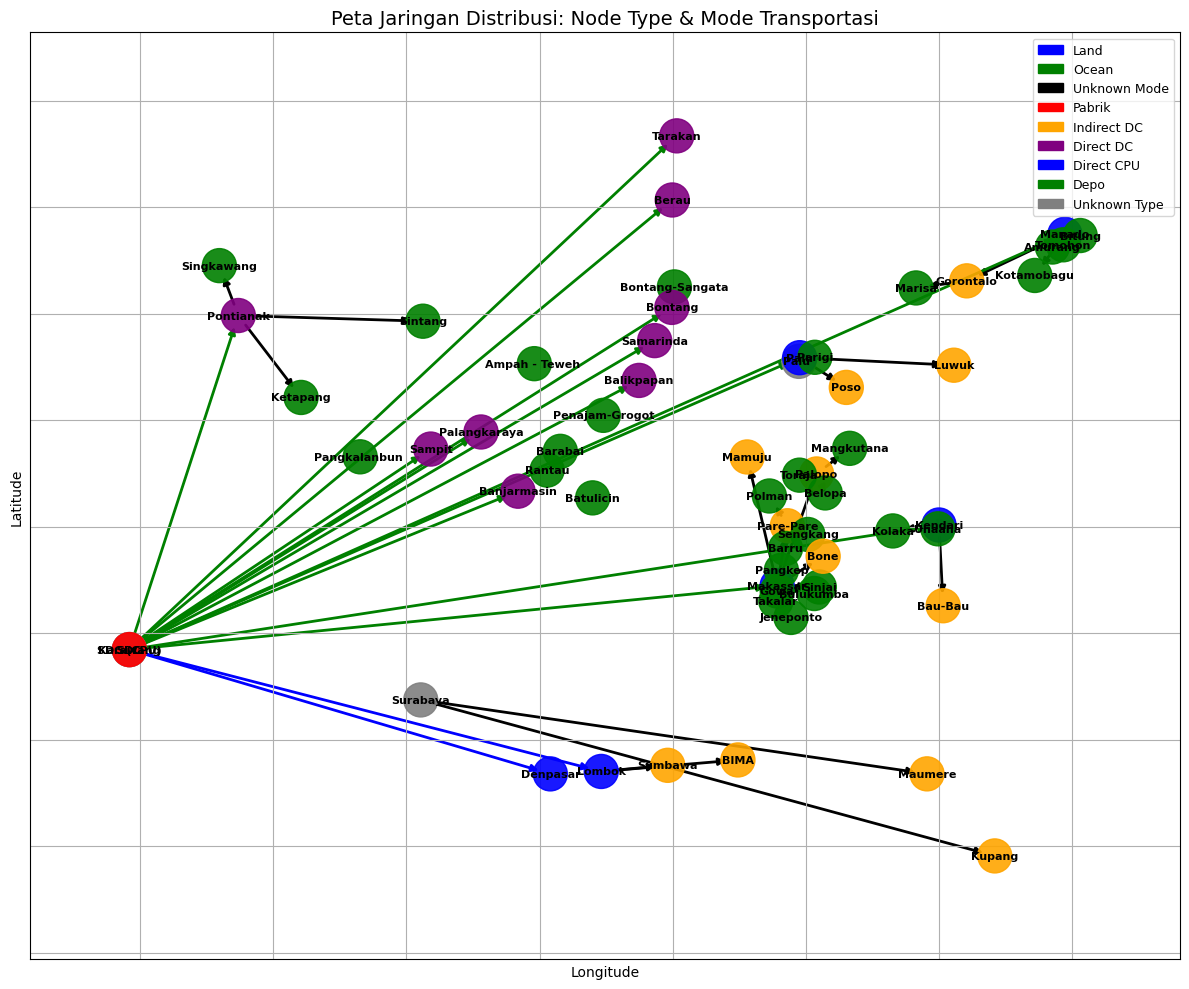

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.patches as mpatches

# --- STEP 1: Siapkan Graph dan Posisi ---
G = nx.DiGraph()

# Buat mapping node_type dari node_id
node_type_dict = dict(zip(df['to_node'], df['node_type']))

# Gabungkan node asal dan tujuan
nodes = pd.concat([
    df[['from_node', 'from_latitude', 'from_longitude']].rename(
        columns={'from_node': 'node', 'from_latitude': 'lat', 'from_longitude': 'lon'}),
    df[['to_node', 'to_latitude', 'to_longitude']].rename(
        columns={'to_node': 'node', 'to_latitude': 'lat', 'to_longitude': 'lon'})
]).dropna(subset=['node']).drop_duplicates(subset='node')

# Tambahkan kolom node_type ke DataFrame nodes berdasarkan mapping
nodes['node_type'] = nodes['node'].map(node_type_dict)

# Mapping warna node berdasarkan jenisnya
node_type_colors = {
    'Pabrik': 'red',
    'Indirect DC': 'orange',
    'Direct DC': 'purple',
    'Direct CPU': 'blue',
    'Depo': 'green'
}

# Tambahkan node ke graf beserta pos dan type
for _, row in nodes.iterrows():
    tipe = row['node_type'] if pd.notna(row['node_type']) else 'Unknown'
    G.add_node(row['node'], pos=(row['lon'], row['lat']), node_type=tipe)

# --- STEP 2: Tambahkan Edge berdasarkan mode_type ---
for _, row in df.dropna(subset=['from_node', 'to_node']).iterrows():
    mode = str(row['mode_type']).lower() if pd.notna(row['mode_type']) else 'unknown'

    if mode == 'ocean':
        color = 'green'
    elif mode == 'land':
        color = 'blue'
    else:
        color = 'black'

    G.add_edge(row['from_node'], row['to_node'], color=color, mode=mode)

# --- STEP 3: Visualisasi ---
pos = nx.get_node_attributes(G, 'pos')
edge_colors = [G[u][v]['color'] for u, v in G.edges()]
node_types = nx.get_node_attributes(G, 'node_type')
node_colors = [node_type_colors.get(node_types.get(n, 'Unknown'), 'gray') for n in G.nodes()]

plt.figure(figsize=(12, 10))

# Gambar node berwarna
nx.draw_networkx_nodes(G, pos, node_size=600, node_color=node_colors, alpha=0.9)

# Gambar edge
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=2)

# Gambar label node
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

# --- Legenda Warna Edge ---
legend_edges = [
    mpatches.Patch(color='blue', label='Land'),
    mpatches.Patch(color='green', label='Ocean'),
    mpatches.Patch(color='black', label='Unknown Mode')
]

# --- Legenda Warna Node ---
legend_nodes = [
    mpatches.Patch(color='red', label='Pabrik'),
    mpatches.Patch(color='orange', label='Indirect DC'),
    mpatches.Patch(color='purple', label='Direct DC'),
    mpatches.Patch(color='blue', label='Direct CPU'),
    mpatches.Patch(color='green', label='Depo'),
    mpatches.Patch(color='gray', label='Unknown Type')
]

plt.legend(handles=legend_edges + legend_nodes, loc='upper right', fontsize=9)

plt.title("Peta Jaringan Distribusi: Node Type & Mode Transportasi", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()


In [ ]:
df_clean = df.dropna(subset=['from_latitude', 'from_longitude', 'to_latitude', 'to_longitude']).copy()

from geopy.distance import geodesic

df_clean['distance_km'] = df_clean.apply(lambda row:
    geodesic((row['from_latitude'], row['from_longitude']),
             (row['to_latitude'], row['to_longitude'])).km,
    axis=1
)

df_clean['distance_km'] = df_clean['distance_km'].round(2)


In [ ]:
df_clean.sample(10)


,node_id,node_type,to_node,region,to_latitude,to_longitude,from_node,mode,volume_cbm,cost_idr,mode_type,from_latitude,from_longitude,distance_km
20,DC021,Depo,Polman,BCP Outer,-3.420450,119.316940,Pare-Pare,NaN,NaN,NaN,NaN,-3.979290,119.654720,72.30
51,DC042,Direct DC,Pontianak,Kalimantan,-0.031090,109.342500,SDC,20FT,1160,11365344.0,Ocean,-6.305384,107.296913,730.07
60,DC047,Indirect DC,BIMA,BCP Outer,-8.377590,118.725640,Lombok,NaN,NaN,NaN,NaN,-8.593730,116.158760,283.64
39,DC035,Direct CPU,Manado,BCP Outer,1.495180,124.865970,SDC,20FT,1160,13200000.0,Ocean,-6.305384,107.296913,2134.58
43,DC037,Direct DC,Balikpapan,Kalimantan,-1.249963,116.868785,SDC,20FT,1160,11214769.0,Ocean,-6.305384,107.296913,1200.93
68,DC055,Indirect DC,Pare-Pare,BCP Outer,-3.979290,119.654720,Makassar,NaN,NaN,NaN,NaN,-5.104040,119.462980,126.18
61,DC048,Indirect DC,Bone,BCP Outer,-4.551810,120.326400,Makassar,NaN,NaN,NaN,NaN,-5.104040,119.462980,113.59
18,DC019,Depo,Parigi,BCP Outer,-0.815640,120.170090,Palu,NaN,NaN,NaN,NaN,-0.891700,119.870700,34.37
29,DC030,Depo,Unaaha,BCP Outer,-4.036810,122.481130,Kendari,NaN,NaN,NaN,NaN,-3.965130,122.501270,8.24
35,DC033,Direct CPU,Lombok,BCP Outer,-8.593730,116.158760,SDC (CPU),CDD (7 CBM),280,13000000.0,Land,-6.305384,107.296913,1010.35


In [ ]:
df_model = df_clean[[
    'from_node', 'to_node', 'mode', 'mode_type', 'volume_cbm', 'distance_km', 'cost_idr'
]].dropna()

df_kendaraan_info = pd.DataFrame({
    'type': ['CDD', 'CDE', 'GrandMax', 'Kijang', 'Motorbike'],
    'kapasitas_cbm': [280, 200, 120, 80, 5],
    'petrol_per_100km': [4, 7, 8, 10, 15]
})


In [ ]:
# --- STEP 2: Ambil dari df_resources ---
vehicle_cols = ['CDD', 'CDE', 'GrandMax', 'Kijang']
df_vehicle = df_resources[['Branch'] + vehicle_cols].copy()

# Pastikan semua kolom kendaraan numerik
for col in vehicle_cols:
    df_vehicle[col] = pd.to_numeric(df_vehicle[col], errors='coerce').fillna(0)

# --- STEP 3: Long Format ---
df_long = df_vehicle.melt(id_vars='Branch', var_name='type', value_name='jumlah_unit')
df_long = df_long[df_long['jumlah_unit'] > 0]

# Gabung dengan info kapasitas & BBM
df_long = df_long.merge(df_kendaraan_info, on='type', how='left')

# Hitung total kapasitas dan konsumsi BBM
df_long['total_kapasitas'] = df_long['jumlah_unit'] * df_long['kapasitas_cbm']
df_long['total_petrol'] = df_long['jumlah_unit'] * df_long['petrol_per_100km']

# --- STEP 4: Agregasi per Branch ---
df_summary = df_long.groupby('Branch').agg({
    'jumlah_unit': 'sum',
    'total_kapasitas': 'sum',
    'total_petrol': 'sum'
}).reset_index()

df_summary = df_summary.rename(columns={
    'jumlah_unit': 'origin_total_vehicle',
    'total_kapasitas': 'origin_total_capacity_cbm',
    'total_petrol': 'origin_total_petrol_per_100km'
})

df_summary['origin_avg_petrol_per_100km'] = (
    df_summary['origin_total_petrol_per_100km'] / df_summary['origin_total_vehicle']
).round(2)

# --- STEP 5: One-hot ketersediaan kendaraan ---
df_availability = df_vehicle.copy()
for col in vehicle_cols:
    df_availability[col] = (df_availability[col] > 0).astype(int)

df_availability = df_availability.rename(columns={
    'CDD': 'CDD_available',
    'CDE': 'CDE_available',
    'GrandMax': 'GrandMax_available',
    'Kijang': 'Kijang_available'
})

# --- FINAL OUTPUT ---
print("✅ df_summary:")
print(df_summary.head())

print("\n✅ df_availability:")
print(df_availability.head())

✅ df_summary:
        Branch  origin_total_vehicle  origin_total_capacity_cbm  \
0         Bali                  19.0                     3880.0   
1   Balikpapan                  14.0                     2880.0   
2  Banjarmasin                  26.0                     5280.0   
3      Bau-Bau                   1.0                      200.0   
4        Berau                   3.0                      520.0   

   origin_total_petrol_per_100km  origin_avg_petrol_per_100km  
0                          130.0                         6.84  
1                           89.0                         6.36  
2                          167.0                         6.42  
3                            7.0                         7.00  
4                           20.0                         6.67  

✅ df_availability:
    Branch  CDD_available  CDE_available  GrandMax_available  Kijang_available
0     Bima              0              1                   0                 0
1   Lombok           

In [ ]:
import pandas as pd
from geopy.distance import geodesic
from tqdm import tqdm


# Mencari demand untuk setiap tempat (salah)

In [ ]:
# # Load file Excel
# file_path = "1742574481558_Dataset-ME-2025.xlsx"
# df_customer = pd.read_excel(file_path, sheet_name="Customer Final")
# df_dc = pd.read_excel(file_path, sheet_name="Dist Center")

# # Ambil kolom penting dan hapus NaN
# df_customer = df_customer[['Customer ID', 'Latitude', 'Longitude', 'Avg Monthly Demand (box)']].dropna()
# df_dc = df_dc[['DC ID', 'Latitude', 'Longitude']].dropna()

# # Inisialisasi list untuk hasil terdekat
# closest_dcs = []

# # Loop setiap customer
# for idx, cust in tqdm(df_customer.iterrows(), total=len(df_customer)):
#     cust_loc = (cust['Latitude'], cust['Longitude'])

#     # Hitung jarak ke semua DC
#     df_dc['Distance'] = df_dc.apply(
#         lambda dc: geodesic(cust_loc, (dc['Latitude'], dc['Longitude'])).km,
#         axis=1
#     )

#     # Cari DC terdekat
#     nearest = df_dc.loc[df_dc['Distance'].idxmin()]
#     closest_dcs.append({
#         'Customer ID': cust['Customer ID'],
#         'Nearest DC ID': nearest['DC ID'],
#         'Distance_km': round(nearest['Distance'], 2),
#         'Avg Monthly Demand (box)': cust['Avg Monthly Demand (box)']
#     })

# # Simpan hasil ke DataFrame
# df_result = pd.DataFrame(closest_dcs)

# # Simpan ke file Excel
# df_result.to_excel("assigned_demand_to_nearest_dc.xlsx", index=False)

100%|██████████| 117801/117801 [03:06<00:00, 632.16it/s]


In [11]:
# Lihat beberapa baris awal dari sheet DC
df_dc = pd.read_excel(xls, sheet_name="DC", header=3)
df_dc.head()


,Balikpapan,DC037,LTA,Kalimantan,Balikpapan.1,Direct DC,SDC,Unnamed: 7,-1.249963,116.868785,10546.38099,12817.452801,70k/yr
0,Banjarmasin,DC038,LTA,Kalimantan,Banjarmasin,Direct DC,SDC,NaN,-3.330249,114.595582,24354.276222,38897.188196,70k/yr
1,Barabai,DC003,LTA,Kalimantan,Barabai,Depo,NaN,NaN,-2.581936,115.390569,NaN,NaN,2k/yr
2,Barru,DC004,BCP,BCP Outer,Barru,Depo,Pare-Pare,NaN,-4.405620,119.618770,NaN,NaN,2k/yr
3,Batulicin,DC005,LTA,Kalimantan,Batulicin,Depo,NaN,NaN,-3.455801,115.997490,NaN,NaN,2k/yr
4,Bau-Bau,DC046,BCP,BCP Outer,Bau-Bau,Indirect DC,Kendari,NaN,-5.481590,122.580000,4042.801010,4414.053861,40k/yr
